# **Spatial Operations in Image Processing**:
Spatial operations use  pixels in a neighborhood to determine the present pixel value. Some applications include filtering and sharpening. They are used in many steps in computer vision, such as segmentation, and are a key building block in Artificial Intelligence algorithms.

In [2]:
!wget -q https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/cameraman.jpeg
!wget -q https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png
!wget -q https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/barbara.png

In [3]:
# Used to view the images
import matplotlib.pyplot as plt
# Used to load an image
from PIL import Image
# Used to create kernels for filtering
import numpy as np

In [4]:
def plot_image(image_1, image_2,title_1="Orignal",title_2="New Image"):
    plt.figure(figsize=(10,10))
    plt.subplot(1, 2, 1)
    plt.imshow(image_1)
    plt.title(title_1)
    plt.subplot(1, 2, 2)
    plt.imshow(image_2)
    plt.title(title_2)
    plt.show()

# Linear Filtering

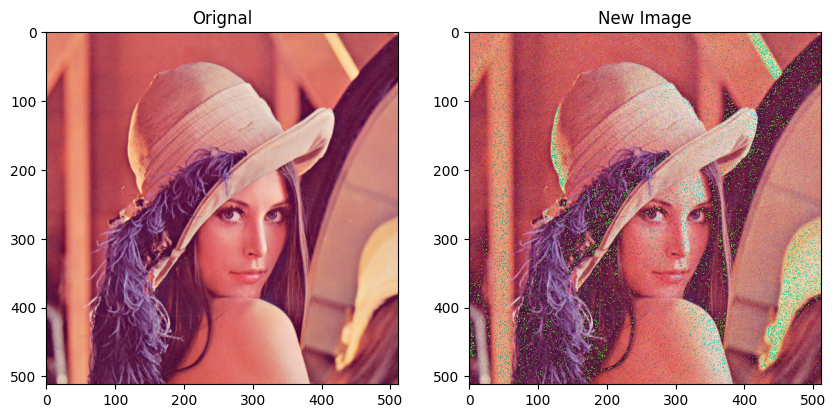

In [25]:
image = Image.open("lenna.png")

#get the number of rows, col
rows, cols = image.size
# Creates vlaues using normal distribution with 0 mean and 15 standard deviation
# the values are converted to uint8 which means the values are in between 0-255
noise = np.random.normal(0,15,(rows, cols, 3)).astype(np.uint8)
noisy_img = image + noise
# Creates a PIL Image from an array
noisy_img = Image.fromarray(noisy_img)

plot_image(image,noisy_img)

**1. Filter Noise**
Smoothing filters average out the Pixels within a neighborhood, they are sometimes called low pass filters.

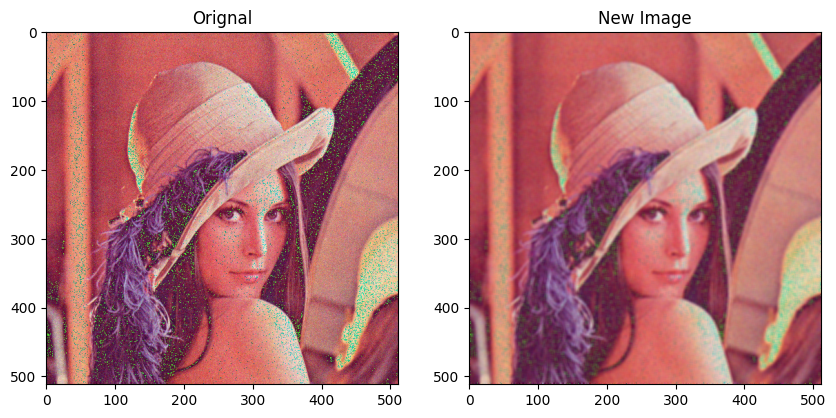

In [13]:
from PIL import ImageFilter

# Creates a Kernel which is a 5x5 array where each value is 1/36
kernel = np.ones((5,5))/36
# Creates a ImageFilter kernel by providing size and flattened kernel
kernel_filter = ImageFilter.Kernel((5,5), kernel.flatten()) # flatten convert 2D to 1D arrray
#filters the image using kernel
filtered_img = noisy_img.filter(kernel_filter)

plot_image(noisy_img,filtered_img)


We see the noise is reduced, but the image is blurry | A smaller kernel keeps the image sharp, but filters less noise, here we try a 3x3 kernel. You can see her shoulders are sharper in this image but the green noise is brighter than the filtered image above.

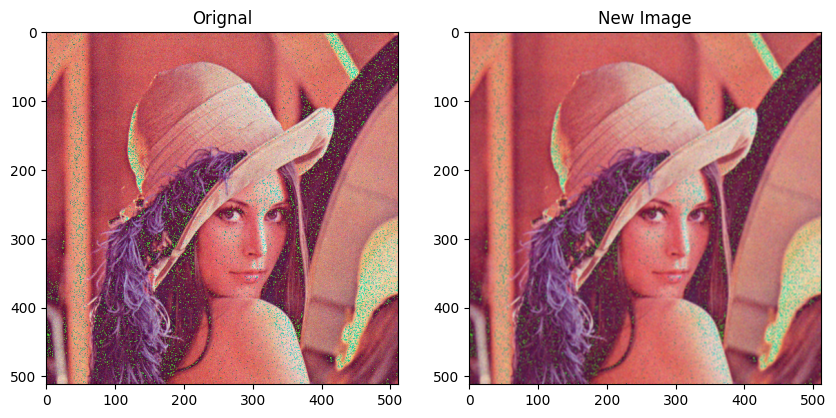

In [16]:
# Creates 3x3 kernel
kernel = np.ones((3,3))/36
kernel_filter = ImageFilter.Kernel((3,3), kernel.flatten())
filtered_img = noisy_img.filter(kernel_filter)

plot_image(noisy_img,filtered_img)

**2. Gaussian Blur**
To perform Gaussian Blur we use the filter function on an image using the predefined filter ImageFilter.GaussianBlur

Parameters

radius: blur kernel radius, default 2

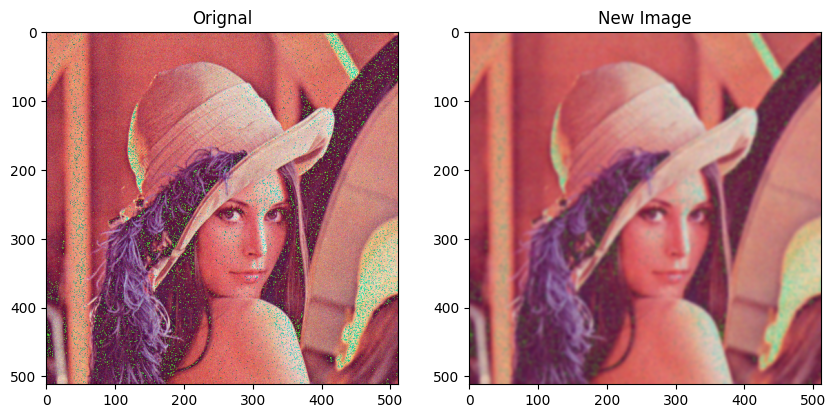

In [17]:
# Filters the image using GaussianBlur
filterred_img = noisy_img.filter(ImageFilter.GaussianBlur)

plot_image(noisy_img,filterred_img)

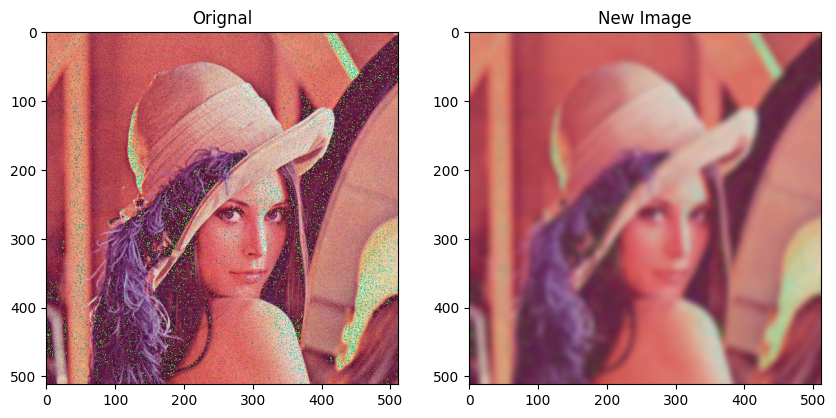

In [18]:
# Lets try using 4x4
filterred_img = noisy_img.filter(ImageFilter.GaussianBlur(4))

plot_image(noisy_img,filterred_img)

**Image Sharpening** Image Sharpening involves smoothing the image and calculating the derivatives. We can accomplish image sharpening by applying the following Kernel.

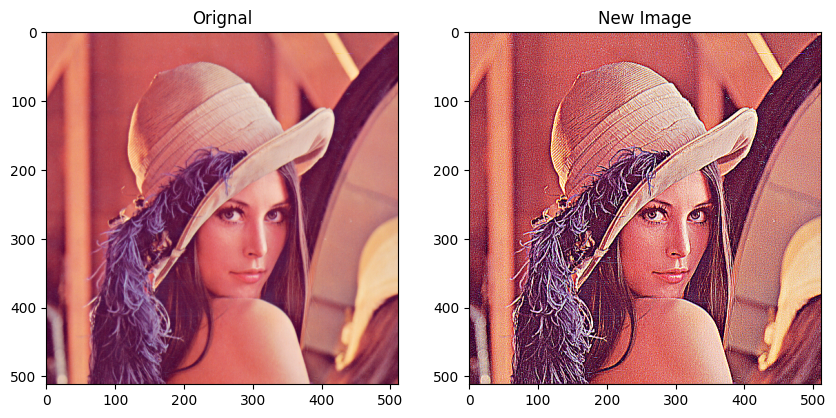

In [27]:
# common kernel for image sharpening
kernel = np.array([[-1,-1,-1],
                   [-1, 9,-1],
                   [-1,-1,-1]])
kernel_filter = ImageFilter.Kernel((3,3), kernel.flatten())
sharpened = image.filter(kernel_filter)

plot_image(image,sharpened)

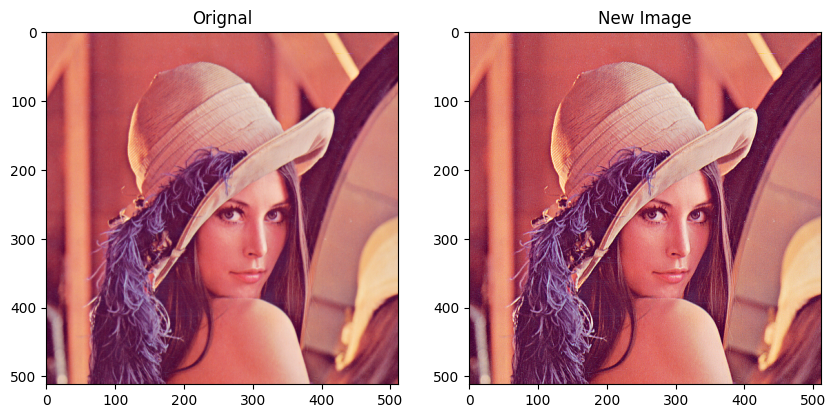

In [26]:
# Sharpends image using predefined image filter from PIL
sharpened = image.filter(ImageFilter.SHARPEN)
plot_image(image,sharpened)

# Edges<br>
Edges are where pixel intensities change. The Gradient of a function outputs the rate of change; we can approximate the gradient of a grayscale image with convolution.

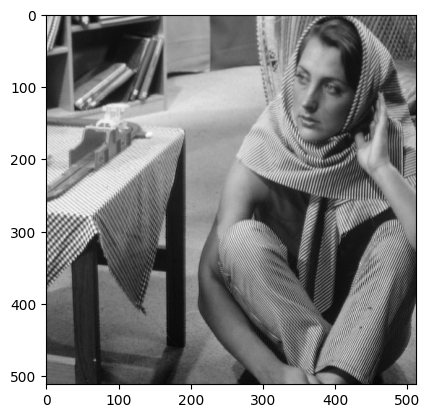

In [31]:
img_gray = Image.open("barbara.png")
# Renders the image from the array of data, notice how it is 2 diemensional instead of 3 diemensional because it has no color
plt.imshow(img_gray ,cmap='gray')


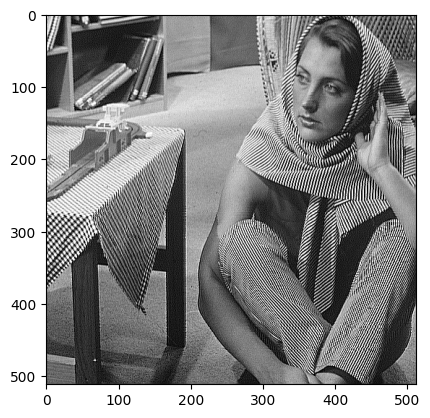

In [32]:
# Filters the images using EDGE_ENHANCE filter
img_gray = img_gray.filter(ImageFilter.EDGE_ENHANCE)
# Renders the enhanced image
plt.imshow(img_gray ,cmap='gray')

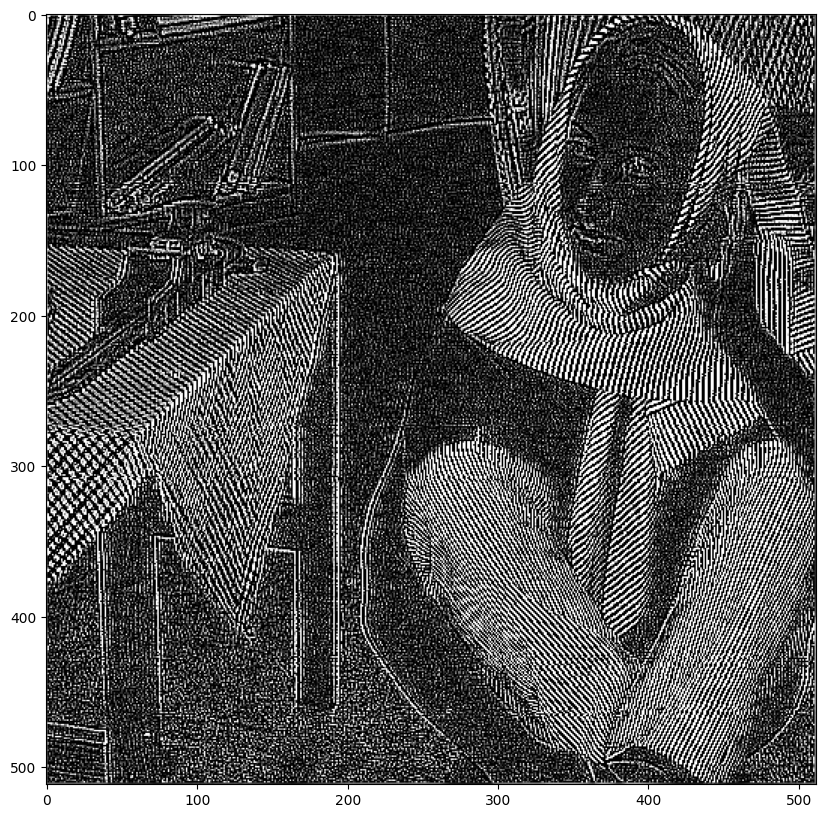

In [33]:
# Filters the images using FIND_EDGES filter
img_gray = img_gray.filter(ImageFilter.FIND_EDGES)
# Renders the filtered image
plt.figure(figsize=(10,10))
plt.imshow(img_gray ,cmap='gray')

# Mean
Median filters find the median of all the pixels under the kernel area and the central element is replaced with this median value.

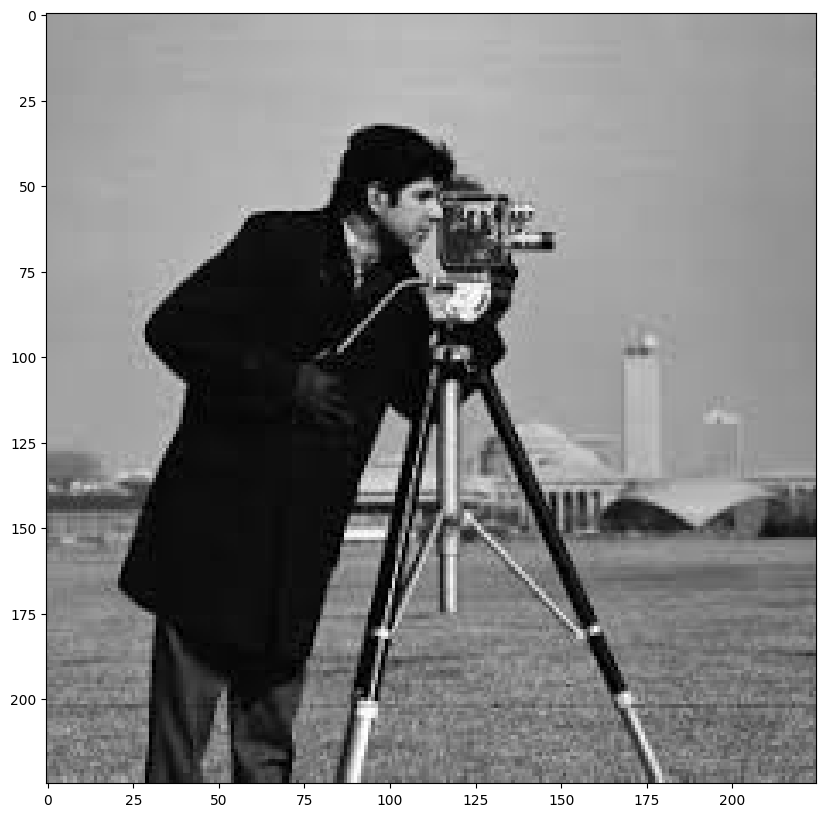

In [38]:
# Load the camera man image
image = Image.open("cameraman.jpeg")
# Make the image larger when it renders
plt.figure(figsize=(10,10))
# Renders the image
plt.imshow(image,cmap="gray")

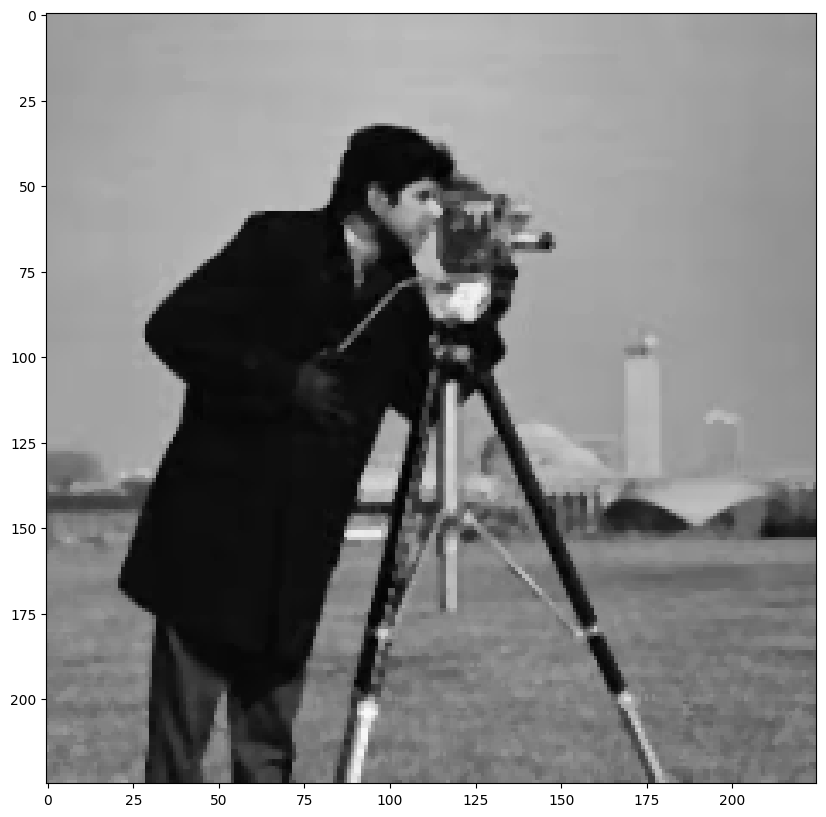

In [39]:
image = image.filter(ImageFilter.MedianFilter)
plt.figure(figsize=(10,10))
# Renders the image
plt.imshow(image,cmap="gray")